In [32]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms
from usecases.utils.test_nb_functions import zeros_poles_freq_to_positions, plot_responses

In [33]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
    v = torch.backends.cudnn.version()
    print(f"cuDNN: {v//10000}.{(v%1000)//100}.{v%100}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


In [34]:
'''
filename = "Zouti_300_AP"
tmp = np.loadtxt(sample_dir / (filename + '.dat'), skiprows=1)
headers = "Frequency (Hz), Gain (dB), Phase (rad)"
np.savetxt(filename + '.csv', tmp, 
           delimiter=',', 
           fmt='%.2E',
           header=headers,
           comments='')
'''

'\nfilename = "Zouti_300_AP"\ntmp = np.loadtxt(sample_dir / (filename + \'.dat\'), skiprows=1)\nheaders = "Frequency (Hz), Gain (dB), Phase (rad)"\nnp.savetxt(filename + \'.csv\', tmp, \n           delimiter=\',\', \n           fmt=\'%.2E\',\n           header=headers,\n           comments=\'\')\n'

Выбор модели.

In [35]:
model_name = 'TransformerBottleneck-model'
log_name = 'TransformerBottleneck-model_preactivation_verynoisy_kernel_5_bce_50'
from src.models.TransformerBottleneck_model import TransformerBottleneck_model as user_model

Пути к каталогам.

In [36]:
config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{log_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]

Импорт модели.

In [37]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

model = user_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
    net = model,
    checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
    device = device
    )

model.eval()

transform = ConversionTransforms(
    num_iter=2,
    return_input=False
    )

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model.pth


## Чтение данных из csv-файлов

Настройки на инференс данных эксперимента.

In [ ]:
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")
sample_file_name_list = [
    "Zout_300_AP",
    "Zouti_300_AP",
    "Wui_300_DP",
    "Wui_delay_300_DP",
    "G_I_PID_300_DP",
    "G_U_PI_300_DP",
    "G_I_PI_300_DP"
    ]
interp_flag = True
positions_flag = False

Настройки на инференс примеров из тестового набора данных.

In [46]:
sample_dir = Path("usecases/test_samples/very_noisy/")
sample_file_name_list = None
interp_flag = False
positions_flag = True

In [47]:
data_list = []

In [48]:
ext = '.csv'

if sample_file_name_list is None:
    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]

for sample_file_name in sample_file_name_list:
    data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

Координаты нулей/полюсов.

In [49]:
if positions_flag:
    zeros_poles_positions_path = sample_dir/ "test_masks.json"
    assert zeros_poles_positions_path.exists(), f"Config not found: {zeros_poles_positions_path}"
    with open(zeros_poles_positions_path, "r") as f:
        zeros_poles_positions_full = json.load(f)
    zeros_poles_positions_list = []
    for sample_file_name in sample_file_name_list:
        zeros_poles_positions_list.append(zeros_poles_positions_full[sample_file_name])

    for zeros_poles_positions in zeros_poles_positions_list:
        zeros_poles_positions.pop('zero_poles')

    zeros_poles_list = zeros_poles_positions_list.copy()
else:
    zeros_poles_freq_list = [
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": []
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": []
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": [5e3]
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": [5e3]
        },
        {
        "left_poles": [42e3],
        "right_poles": [],
        "left_zeros": [380, 17e3],
        "right_zeros": []
        },
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [270],
        "right_zeros": []
        },
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [1.5e3],
        "right_zeros": []
        }
        
    ]
    zeros_poles_list = zeros_poles_freq_list.copy()

Интерполяция данных (по требованию).

In [50]:
if interp_flag:
    data_list_interp = []
    for data in data_list:
        freq = data[0,:]
        mag_ph = np.array([data[1,:], data[2,:]])

        freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
        mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
        data_interp = np.vstack((freq_log, mag_ph_interp))
        data_list_interp.append(data_interp)
    data_list = data_list_interp.copy()

Инференс.

In [51]:
mask_threshold = model_log["metadata"]["model"]["mask_threshold"]

predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > mask_threshold).float().detach().cpu().numpy())

## Визуализация

In [52]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

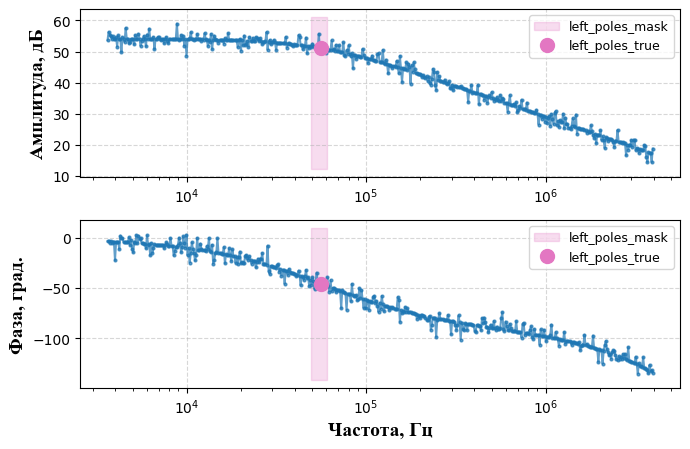

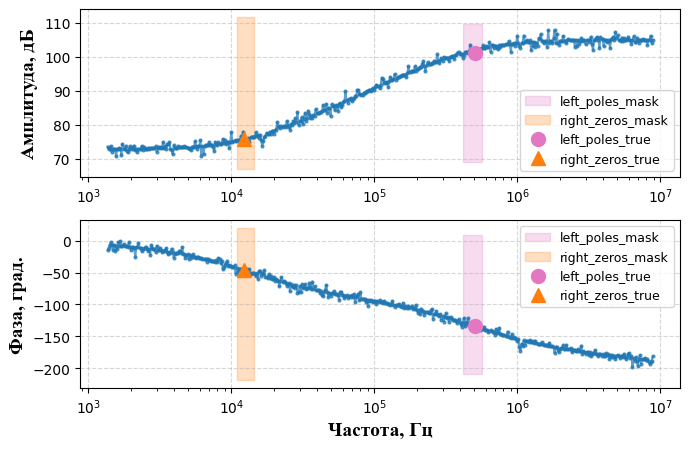

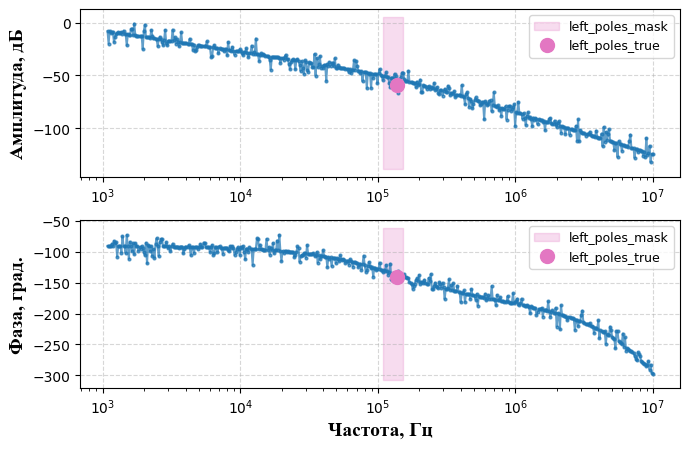

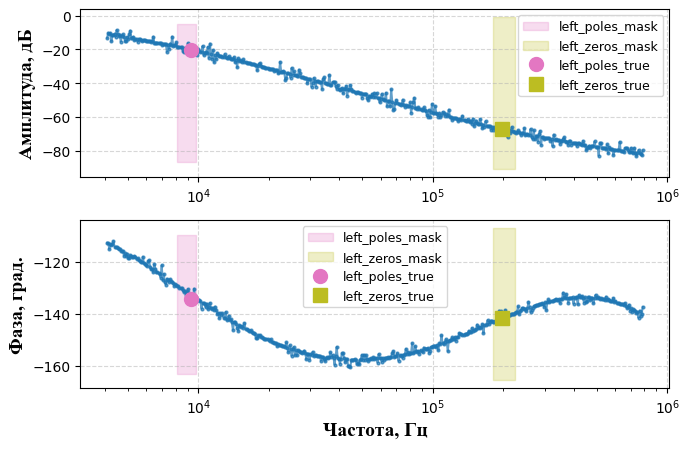

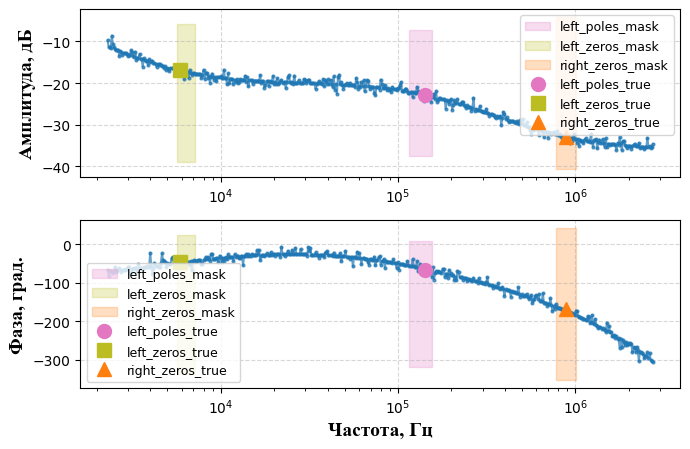

In [53]:
for data, zeros_poles, predictions, sample_file_name in zip(
    data_list,
    zeros_poles_list,
    predictions_list,
    sample_file_name_list
    ):
    if not positions_flag:
        zeros_poles_positions = zeros_poles_freq_to_positions(
            zeros_poles_freq_dict=zeros_poles,
            freq=data[0,:]
            )
    else:
        zeros_poles_positions = zeros_poles.copy()
    
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        #title=sample_file_name,
        regions=predictions,
        zeros_poles_positions=zeros_poles_positions,
        #save_path=f'usecases/test_samples/experiments_13_May_2026/pdf/{sample_file_name}.pdf'
        )

In [101]:
def mask_postprocess(mask: np.ndarray, M: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Filters sequences of '1s' to keep only those with length >= M.
    
    Returns:
        - Middle coordinates of the valid sequences (shape: (N, 2)).
        - Filtered mask (same shape as input, dtype float32).
        - Number of regions before filtering per channel (shape: (num_channels,)).
        - Number of regions after filtering per channel (shape: (num_channels,)).
    """
    results = []
    arr = np.array(mask, dtype=int)
    
    # Initialize the filtered mask with zeros of the same shape
    filtered_mask = np.zeros_like(arr)
    
    # Lists to store counts per channel (row)
    regions_before_per_channel = []
    regions_after_per_channel = []
    
    for row_idx in range(arr.shape[0]):
        row = arr[row_idx]
        
        # Pad with 0 at both ends to correctly catch sequences
        # that start at index 0 or end at the last index.
        padded = np.pad(row, (1, 1), constant_values=0)
        
        # Converts to 1 or -1.
        diff = np.diff(padded)
        
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        
        # Count regions before filtering for this specific channel
        num_before = len(starts)
        regions_before_per_channel.append(num_before)
        
        num_after = 0
        for start, end in zip(starts, ends):
            length = end - start
            if length >= M:
                mid_col = (start + end - 1) // 2
                results.append((row_idx, mid_col))
                
                # Keep the valid sequence in the filtered mask.
                filtered_mask[row_idx, start:end] = 1
                num_after += 1
                
        # Count regions after filtering for this specific channel.
        regions_after_per_channel.append(num_after)
                
    # Convert the per-channel lists to numpy arrays
    regions_before_arr = np.array(regions_before_per_channel, dtype=int)
    regions_after_arr = np.array(regions_after_per_channel, dtype=int)
    
    # Ensure results is a 2D array of shape (N, 2) even if empty.
    if len(results) == 0:
        results =  np.empty((0, 2), dtype=int)
        
    return np.array(results, dtype=int), np.array(filtered_mask, dtype=np.float32), regions_before_arr, regions_after_arr

In [102]:
coords, filtered_mask, num_regions_before, num_regions_after = mask_postprocess(
    mask=predictions,
    M=model_log['metadata']['model']['mask_halfwindow']
    )
freq = data[0, :]
print(freq[coords[0,1]])
print(freq[coords[1,1]])
print(freq[coords[2,1]])

133231.70404536652
6313.001745326457
877627.1934627161


In [106]:
zeros_poles_freq_to_positions(
            zeros_poles_freq_dict=zeros_poles,
            freq=data[0,:]
            )

{'left_poles': array([0]),
 'right_poles': array([], dtype=int64),
 'left_zeros': array([0]),
 'right_zeros': array([0])}

In [ ]:
for data, zeros_poles, predictions, sample_file_name in zip(
    data_list,
    zeros_poles_list,
    predictions_list,
    sample_file_name_list
    ):
    
    freq = data[0,:]
    freq[zeros_poles['left_poles']]
    freq[zeros_poles['right_poles']]
    freq[zeros_poles['left_zeros']]
    freq[zeros_poles['right_zeros']]
    
    coords, _, _, _ = mask_postprocess(
        mask=predictions,
        M=model_log['metadata']['model']['mask_halfwindow']
        )
    


array([1, 0, 1, 1])

In [109]:
data[0,:][zeros_poles['left_zeros']]

array([5890.28831827])